<a href="https://colab.research.google.com/github/rwpursley/Visual-Narratives-from-Real-World-Data/blob/main/Ryan_Pursley_Visual_Narratives_From_Real_World_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#What factors cause smartphone batteries to drain faster?

In [2]:
import pandas as pd

df = pd.read_csv('smartphone_battery_drain_dataset.csv')

df.head()

,App_Running,Screen_On_Time_min,CPU_Usage_%,Battery_Temperature_C,Battery_Drop_Per_Hour,Network_Type,Brightness_Level_%,RAM_Usage_MB,Charging_State,Usage_Mode
0,Facebook,70.779244,55.550655,34.301005,6.020228,5G,57,2941.852469,Charging,Gaming
1,PUBG,90.044282,10.506832,35.607895,13.372379,WiFi,10,1930.581458,Not Charging,Social Media
2,Maps,75.197224,38.529769,43.312775,3.514550,5G,37,2169.828899,Charging,Social Media
3,WhatsApp,114.762495,26.898454,33.795197,6.728475,WiFi,33,2329.369145,Charging,Browsing
4,Facebook,52.214675,36.862349,41.089636,19.134837,5G,25,2175.002939,Charging,Video Streaming


In [3]:
df.dtypes

,0
App_Running,object
Screen_On_Time_min,float64
CPU_Usage_%,float64
Battery_Temperature_C,float64
Battery_Drop_Per_Hour,float64
Network_Type,object
Brightness_Level_%,int64
RAM_Usage_MB,float64
Charging_State,object
Usage_Mode,object


In [4]:
df.describe()

,Screen_On_Time_min,CPU_Usage_%,Battery_Temperature_C,Battery_Drop_Per_Hour,Brightness_Level_%,RAM_Usage_MB
count,2503.000000,2498.000000,2498.000000,2503.000000,2503.000000,2503.000000
mean,79.800996,34.480392,34.989399,11.948375,51.902917,2197.331721
std,24.602660,15.003228,5.148660,4.843174,27.520267,589.813489
min,5.000000,1.000000,20.000000,1.000000,5.000000,500.000000
25%,62.817364,24.231843,31.522576,8.627100,27.000000,1797.226777
50%,79.865066,34.245258,34.983050,11.849516,52.000000,2196.626984
75%,96.825940,44.617992,38.508336,15.139305,76.000000,2596.435063
max,156.548674,83.602087,52.720325,27.516922,99.000000,4145.699243


In [5]:
df.corr(numeric_only=True)

,Screen_On_Time_min,CPU_Usage_%,Battery_Temperature_C,Battery_Drop_Per_Hour,Brightness_Level_%,RAM_Usage_MB
Screen_On_Time_min,1.000000,-0.010911,0.028137,0.039654,0.027186,0.001292
CPU_Usage_%,-0.010911,1.000000,0.037816,-0.013925,-0.005801,0.026574
Battery_Temperature_C,0.028137,0.037816,1.000000,0.023319,-0.003251,-0.004167
Battery_Drop_Per_Hour,0.039654,-0.013925,0.023319,1.000000,-0.026316,-0.026144
Brightness_Level_%,0.027186,-0.005801,-0.003251,-0.026316,1.000000,-0.017577
RAM_Usage_MB,0.001292,0.026574,-0.004167,-0.026144,-0.017577,1.000000


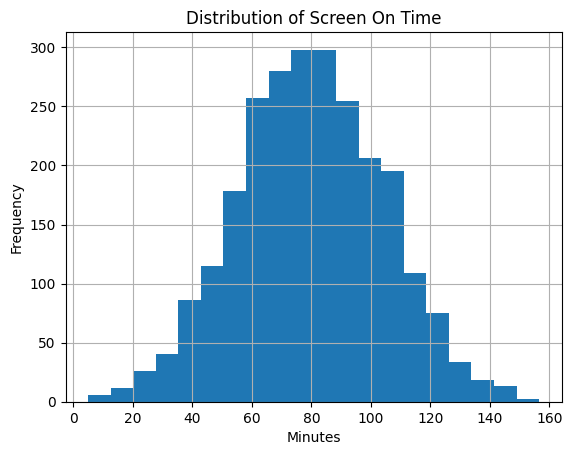

In [6]:
import matplotlib.pyplot as plt

df['Screen_On_Time_min'].hist(bins=20)
plt.title("Distribution of Screen On Time")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

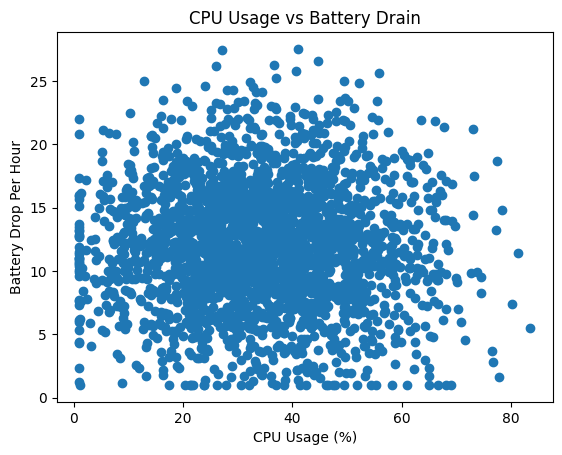

In [7]:
plt.scatter(df['CPU_Usage_%'], df['Battery_Drop_Per_Hour'])
plt.title("CPU Usage vs Battery Drain")
plt.xlabel("CPU Usage (%)")
plt.ylabel("Battery Drop Per Hour")
plt.show()

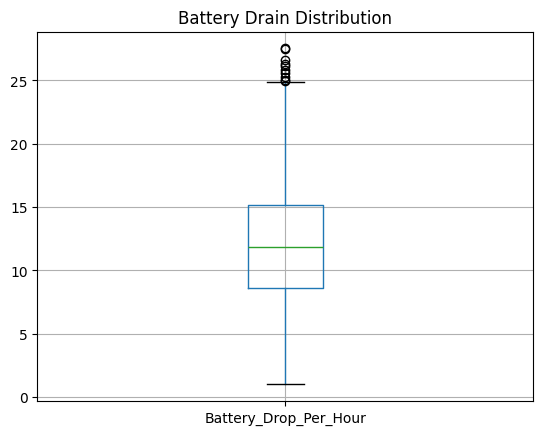

In [8]:
df.boxplot(column='Battery_Drop_Per_Hour')
plt.title("Battery Drain Distribution")
plt.show()

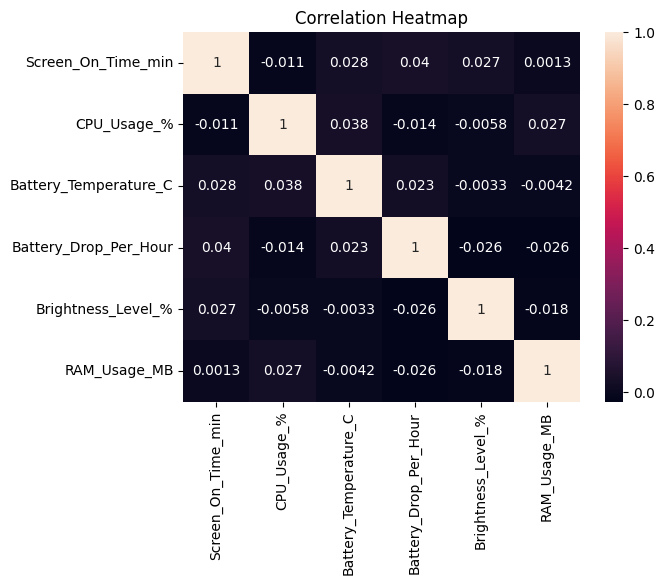

In [9]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [10]:
import plotly.express as px

fig = px.scatter(
    df,
    x="CPU_Usage_%",
    y="Battery_Drop_Per_Hour",
    color="Usage_Mode",
    title="CPU Usage vs Battery Drain by Usage Mode"
)

fig.show()

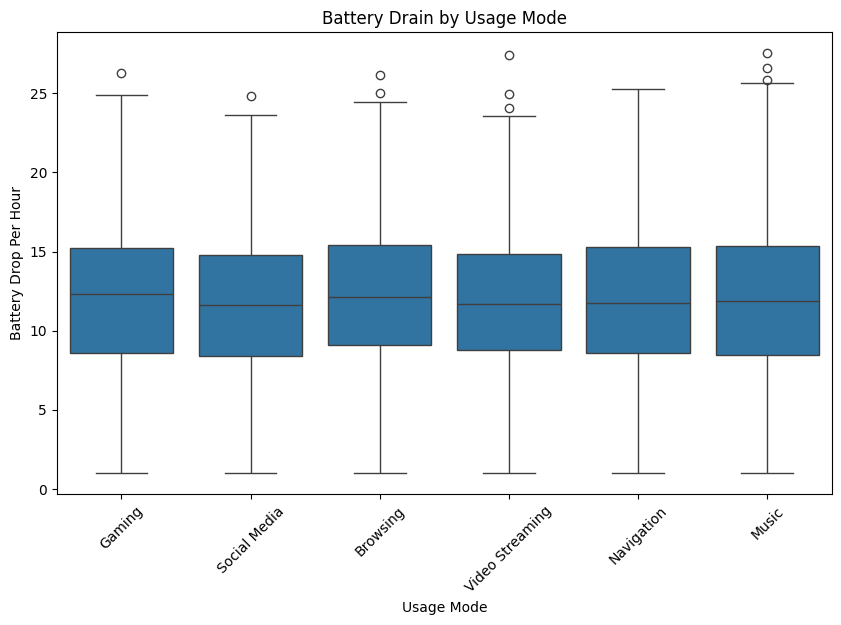

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x="Usage_Mode", y="Battery_Drop_Per_Hour", data=df)

plt.title("Battery Drain by Usage Mode")
plt.xlabel("Usage Mode")
plt.ylabel("Battery Drop Per Hour")

plt.xticks(rotation=45)
plt.show()

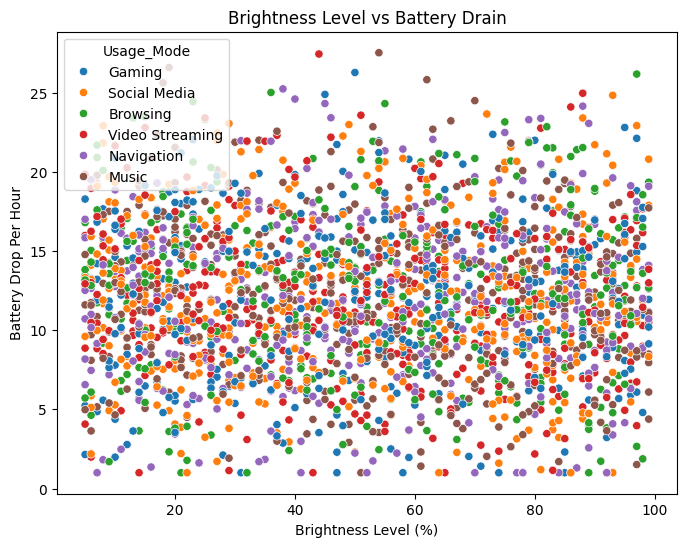

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Brightness_Level_%",
    y="Battery_Drop_Per_Hour",
    hue="Usage_Mode",
    data=df
)

plt.title("Brightness Level vs Battery Drain")
plt.xlabel("Brightness Level (%)")
plt.ylabel("Battery Drop Per Hour")

plt.show()

### Key Insights

1.   Higher CPU usage tends to correspond with faster battery drain.
2.   Higher screen brightness appears to increase battery consumption.
3.  Certain usage modes, such as gaming and streaming, result in higher CPU and RAM usage.
4.  Devices using mobile networks may experience faster battery drain compared to WiFi.

